## 0) Imports and stuff

In [1]:
"""from google.colab import drive
drive.mount('/content/drive')"""

"from google.colab import drive\ndrive.mount('/content/drive')"

In [1]:
# cd "drive/MyDrive/tests-sara"

In [1]:

%load_ext autoreload
%autoreload 2


In [2]:
from data_processing.dataloader import get_BAA_DFS
from data_processing.dataset import BAA_Dataset
from data_processing.preprocessing import get_transforms
from model.model import BAA_resnet18, BoneAgeEfficientNet
from model.train import train_model
from model.eval import evaluate
from model.gradcam import GradCAM

from torch.utils.data import DataLoader
import torch
import matplotlib.pyplot as plt
import numpy as np
from os import path, listdir, getcwd, makedirs
from pathlib import Path

import cv2 as cv
from PIL import Image
import torch.nn.functional as F

In [3]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # i have limited GPU unfortunately

In [3]:
device = torch.device('cpu') 

In [4]:
print('Device: {}'.format(device))

Device: cpu


## 1) Data preparation

In [5]:
batch_size = 64
num_workers = 3

target_image_size = (1024,1024)

### 1.1) Loading data

In [6]:
## wherever you stored data: this folder needs to have the .csv, and you need to specify folder names for where to get ur images
## if you don't want to apply segmentation, just set the flag to false and make sure the image files are named as in RSNA
## if you don't have have one just put none -> will download with kagglehub library
apply_segmentation = True
datapath = path.join(getcwd(), "data")

In [7]:
# you will need to include kagglehub in dependencies if folders don't exist
train_df, val_df = get_BAA_DFS(seed = 42, datapath = datapath, image_folder = "masks", apply_segmentation = apply_segmentation)

finished checking

Full df size len: 4226
train/val sizes: 3380/846


### 1.2) Transforms

In [8]:
transforms = get_transforms(target_size = target_image_size, include_resize = True, color_channels_nb = 3)
#min_transforms = get_min_transforms(color_channels_nb = 1)

### 1.3) Dataset

In [9]:
train_dataset = BAA_Dataset(train_df, transforms, apply_segmentation = apply_segmentation)
val_dataset = BAA_Dataset(val_df, transforms, apply_segmentation)

#### visualize

In [10]:
def denormalize(img):
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return img

# to display normalized images with matplotlib - not necessary if images are processed in grayscale

get image: done - img shape = (3, 1024, 1024)


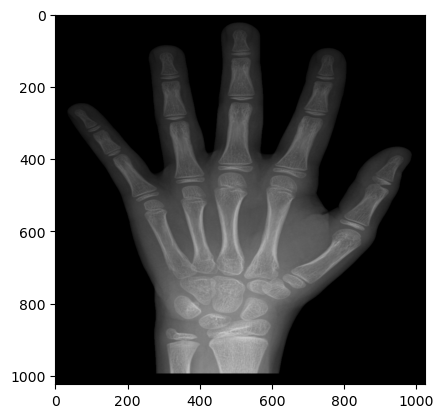

In [171]:
img, _, _ = val_dataset.__getitem__(4)
img = img.squeeze(0).cpu()
img = denormalize(img)
# if 3 color channels:
img = img.permute(1,2,0)
plt.imshow(img)

### 1.4) DataLoader

In [11]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)

## 2) Model

### 2.1) Initial Resnet18

In [3]:
# model = BAA_resnet18().to(device)
# model_type = 'resnet18'

In [12]:
model = BoneAgeEfficientNet(model_name = "tf_efficientnet_b4.ns_jft_in1k", hidden_dim = 1024).to(device)
model_type = 'efficientnet'

### 2.2) Loading a Checkpoint

In [13]:
checkpoint_path = path.join(getcwd(), "model", "checkpoints")
specific_checkpoint = "efficientnet_b4_1024x1024_aug_geo_best.pth"

In [14]:
p = path.join(checkpoint_path, specific_checkpoint)
if path.exists(p):
    checkpoint = torch.load(p, weights_only=False, map_location=torch.device('cpu'))
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    print("checkpoint doesn't exist")

## 3) Training

In [101]:
learning_rate = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
criterion = torch.nn.L1Loss()
n_epochs = 0

### 3.1) Training loop

In [18]:
train_losses = []
val_losses = []

In [45]:
# train_losses, val_losses = train_model(model, train_dataloader, val_dataloader, n_epochs, device, optimizer, criterion, checkpoint_path)

### 3.2) Eval only

In [19]:
mae = None
# mae = evaluate(model, val_dataloader, device, criterion)

In [2]:
print(mae)

None


### 3.3) Visualizing results

In [ ]:
if len(val_losses) > 0:
    print(train_losses[-1], val_losses[-1])

    mae = val_losses / val_dataset.shape[0]

    plt.figure()
    plt.plot(np.arange(len(train_losses)), train_losses)
    plt.plot(np.arange(len(val_losses)), val_losses)
    plt.legend(['train_loss', 'val_loss'])
    plt.xlabel('epoch')
    plt.ylabel('loss value (boneage months)')
    plt.title('{}: Train/val loss'.format("current model training results"));

### 3.4) Saving current model

In [ ]:
specific_checkpoint = f"checkpoint-{model_type}.pth"

In [ ]:
"""
p = path.join(checkpoint_path, specific_checkpoint)
state_dict = model.state_dict()

if mae is None:
    mae = evaluate(model, val_dataloader, device, criterion)

if path.exists(p):

    checkp = torch.load(p, weights_only=False)
    if checkp['mae'] < mae:
        print('new model sucks')
        state_dict = checkp['model_state_dict']



torch.save({
    'model_state_dict': model.state_dict(),
    'mae': mae
}, p)
"""

## 4) GRAD-Cam

In [15]:
output_dir = path.join(getcwd(), "output")

### 4.1) Set the target layer
You need to define the target layer: usually the last convolutional layer from whichever backbone model you chose.
For Restnet 18, it's divided into 4 "blocks" of layers, we want the last layer of the last block. I no longer specify it inside the model class !

In [16]:
target_layer = None
match model_type:
    case "resnet18":
        target_layer = model.backbone.layer4[-1]
    case "efficientnet":
        target_layer = model.backbone.conv_head
        # target_layer =  model.backbone.blocks[-3] #ou -3
        

### 4.2) Generate Grad-CAM

In [17]:
grad_cam = GradCAM(model, target_layer)

### -- Apply it to a single input

In [85]:
img, gender, age, idx = val_dataset.get_random_items(1)[0]

In [86]:
u_img = img.unsqueeze(0).to(device)
u_gender = gender.unsqueeze(0).to(device)

print(f"img shape: {u_img.shape}, gender shape: {u_gender.shape}")

img shape: torch.Size([1, 3, 1024, 1024]), gender shape: torch.Size([1])


In [87]:
img = denormalize(img).squeeze(0).cpu()

# if 3 color channels:
img = img.permute(1, 2, 0)

In [89]:
cam = grad_cam.generate(u_img, u_gender)
cam = cam.cpu()
resized_cam = grad_cam.resize_cam(cam, target_image_size)

In [90]:
pred = model(u_img, u_gender)

single_rand_sample_cam_over_input_6.png


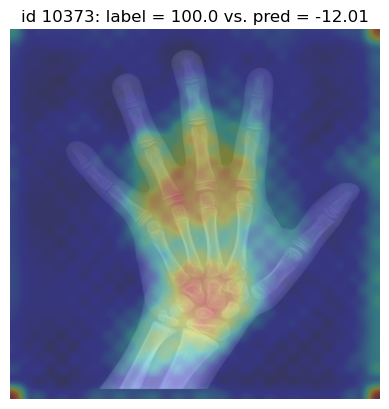

In [91]:
plt.imshow(img, cmap='gray', alpha=0.7)
plt.imshow(resized_cam, cmap='jet', alpha=0.3)
plt.axis('off')
plt.title(f"id {idx}: label = {age:.4} vs. pred = {pred.item():.4}")

p = path.join(output_dir, "single-rand_cam-over-input")
makedirs(p, exist_ok=True)

filename = f"single_rand_sample_cam_over_input_{len(listdir(p))}.png"
plt.savefig(path.join(p, filename), dpi=300, bbox_inches='tight')
print(filename)

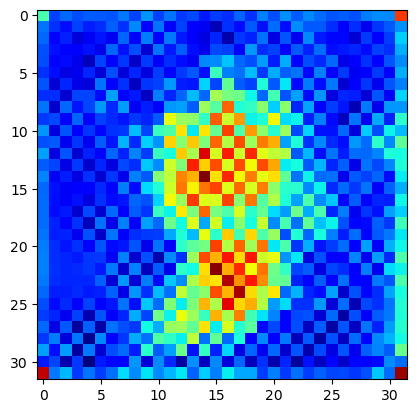

In [92]:
dcam = cam.squeeze().detach().numpy()
plt.imshow(dcam, cmap='jet', alpha=1.0)

### -- use Results to create cropped images

#### get original size

(1470, 1296, 3)


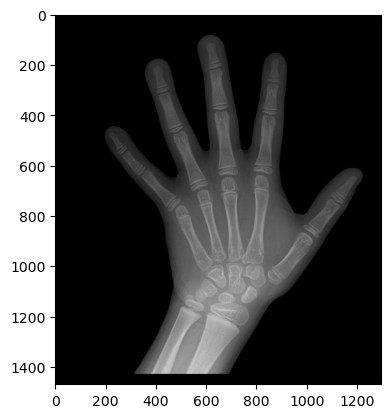

In [93]:
row = val_df.loc[val_df["id"] == idx]
row

full_im = Image.open(row["img_path"].item()).convert("RGB")

full_np = np.array(full_im)


# full_np = full_np.transpose(1, 0, 2)
print(full_np.shape)

plt.imshow(full_im)

In [94]:
scale_x = img.shape[0] / dcam.shape[0]
scale_y = img.shape[1] / dcam.shape[1]

s1 = img.shape[0] / dcam.shape[0]

s2y = full_np.shape[0] / img.shape[0]
s2x = full_np.shape[1] / img.shape[1]

full_width = full_np.shape[1]
full_height = full_np.shape[0]

#### importance map

In [95]:


def compute_region_scores(cam, window_size=5):

    # cam: (1,1,H,W)

    kernel = torch.ones(
        (1, 1, window_size, window_size),
        device=cam.device
    )

    scores = F.conv2d(
        cam,
        kernel,
        padding=window_size // 2
    )

    return scores

scores = compute_region_scores(cam, 3)
scores.shape

torch.Size([1, 1, 32, 32])

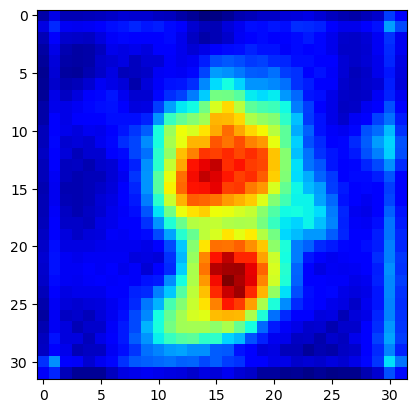

In [96]:
scores_np = scores.squeeze().detach().cpu().numpy()
plt.imshow(scores_np, cmap='jet')

#### get bounding boxes with opencv

In [83]:
threshold = np.quantile(scores_np, 0.95)

binary_mask = (scores_np > threshold).astype(np.uint8)
binary_mask = binary_mask * 255

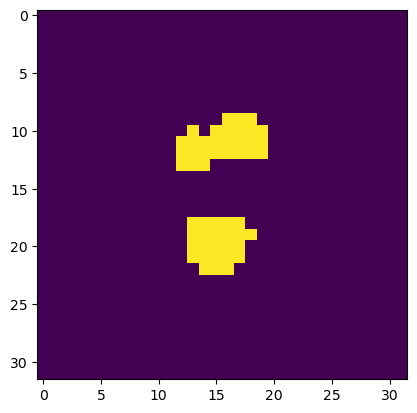

In [84]:
plt.imshow(binary_mask)

In [31]:
contours, hierarchy = cv.findContours(
    binary_mask,
    cv.RETR_EXTERNAL,
    cv.CHAIN_APPROX_SIMPLE
)

In [32]:
cam_vis = cv.cvtColor(scores_np, cv.COLOR_GRAY2BGR)

for contour in contours:

    x, y, w, h = cv.boundingRect(contour)

    cv.rectangle(
        cam_vis,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        1
    )

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


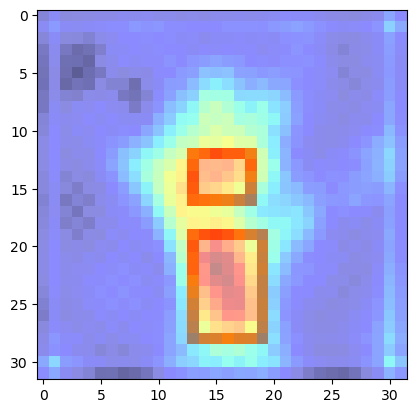

In [37]:
plt.imshow(scores_np, cmap='jet', alpha = 0.9)
plt.imshow(cam_vis, alpha=0.5)

#### scale bboxes to size (1024,1024), crop a bit larger than just bbox size

In [38]:
full_np.shape, scale_x, scale_y, dcam.shape

((1647, 1551, 3), 32.0, 32.0, (32, 32))

13 19 6 9
416.0 608.0 192.0 288.0
13 12 5 4
416.0 384.0 160.0 128.0


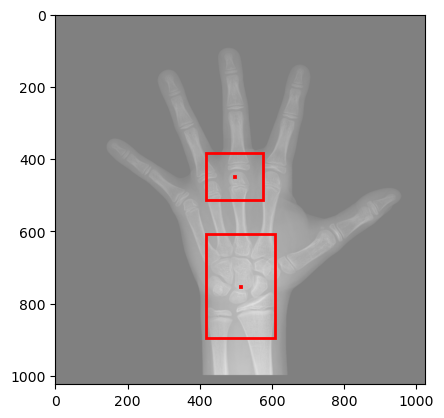

In [45]:
import matplotlib.patches as patches


fig, ax = plt.subplots()

ax.imshow(img, alpha=0.5)

for contour in contours:

    x, y, w, h = cv.boundingRect(contour)

    x1 = x * scale_x
    y1 = y * scale_y

    ws = w * scale_x
    hs = h * scale_y
    
    x2 = (x + w) * scale_x
    y2 = (y + h) * scale_y

    print(x,y,w,h)
    print(x1,y1, ws, hs)

    p1 = x + (w/2)
    p2 = y + (h/2)
    p1 = p1 * scale_x
    p2 = p2 * scale_y

    rect1 = patches.Rectangle(
        (x1, y1),
        ws,
        hs,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )

    rect2 = patches.Rectangle(
        (p1-1, p2-1),
        2,
        2,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )

    ax.add_patch(rect1)
    ax.add_patch(rect2)

plt.show()

#### scale bboxes to full image size, crop a bit larger than just bbox size

14 18 4 5
577.9375 1127.8125 165.125 313.28125
10 8 9 7
412.8125 501.25 371.53125 438.59375
17 6 2 3
701.78125 375.9375 82.5625 187.96875


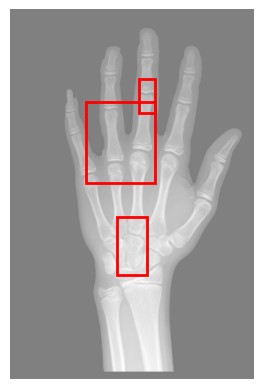

In [293]:
import matplotlib.patches as patches


fig, ax = plt.subplots()

ax.imshow(full_np, alpha=0.5)

for contour in contours:

    x, y, w, h = cv.boundingRect(contour)


    x1 = (x * s1) * s2x
    y1 = (y * s1) * s2y

    ws = (w * s1) * s2x
    hs = (h * s1) * s2y

    print(x,y,w,h)
    print(x1,y1, ws, hs)

    rect = patches.Rectangle(
        (x1, y1),
        ws,
        hs,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )

    ax.add_patch(rect)

plt.axis('off')
plt.show()

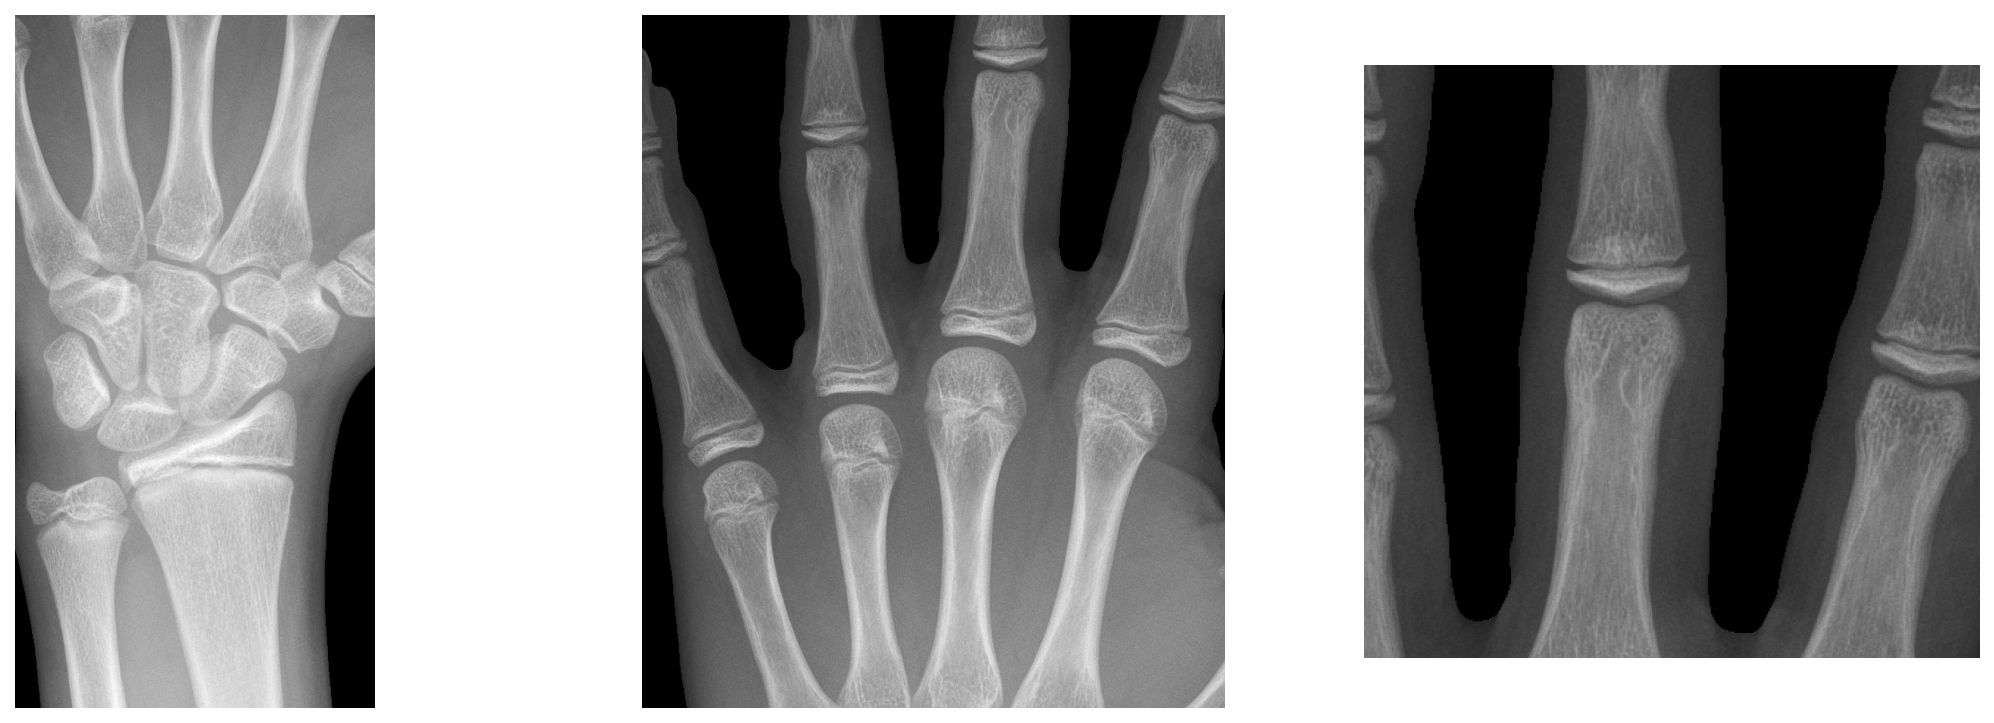

In [297]:
crops = []
crop_ratio = 0.80 # 1.0 is bbox size, the more you reduce the bigger it is from bbox

for contour in contours:

    x, y, w, h = cv.boundingRect(contour)

    x1 = int((x * s1) * s2x) * crop_ratio
    y1 = int((y * s1) * s2y) * crop_ratio
    
    x2 = int(((x + w) * s1) * s2x) / crop_ratio
    y2 = int(((y + h) * s1) * s2y) / crop_ratio

    x1 = max(0, x1)
    y1 = max(0, y1)
    
    x2 = min(full_width, x2)
    y2 = min(full_height, y2)
    
    crop = full_im.crop((x1, y1, x2, y2))
    crops.append(crop)


p = path.join(output_dir, f"ROIs")
makedirs(p, exist_ok=True)

fig, ax = plt.subplots(nrows=1, ncols=len(crops), figsize=(6 * len(crops), 6), dpi=150)

filename = f"{idx}_cropped"
i = 0

for crop, sub_plot in zip(crops, fig.axes):

    sub_plot.imshow(crop)
    sub_plot.axis('off')
    

    crop.save(path.join(p, f"{filename}_{i}.png"))
    i += 1
print(f"saved {str(i + 1)} different cropped images")
        

### -- Apply it to multiple inputs

In [98]:
n = 9
nrows = 3
ncols = 3

In [99]:
rand_inputs = val_dataset.get_random_items(n)

In [ ]:
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 6 * nrows), dpi=150)

for i, test_input, sub_plot in zip(range(n), rand_inputs, fig.axes):

    print(f"{i}", end='\r')
    
    img, gender, age, idx = test_input
    u_img = img.unsqueeze(0).to(device)
    u_gender = gender.unsqueeze(0).to(device)

    cam = grad_cam.generate(u_img, u_gender)
    cam = cam.cpu()
    resized_cam = grad_cam.resize_cam(cam, target_image_size)

    pred = model(u_img, u_gender)

    scores = compute_region_scores(cam, 3)
    scores_np = scores.squeeze().detach().cpu().numpy()


    threshold = np.quantile(scores_np, 0.95)

    binary_mask = (scores_np > threshold).astype(np.uint8)
    binary_mask = binary_mask * 255

    img = denormalize(img).squeeze(0).cpu()
    

    # if 3 color channels:
    img = img.permute(1, 2, 0)

    sub_plot.imshow(img, cmap='gray', alpha=0.7)
    sub_plot.set_title(f"id {idx}: label = {age:.4}, loss = {criterion(age, pred.squeeze(0)):.4}", fontsize = 9)

    sub_plot.axis('off')
    sub_plot.imshow(binary_mask, cmap='jet', alpha=0.3)


p = path.join(output_dir, f"multiple_rand__cam_over_input")
makedirs(p, exist_ok=True)

filename = f"{n}_rand_samples_cam_over_input_{len(listdir(p))}.png"
plt.savefig(path.join(p, filename), dpi=300, bbox_inches='tight')

5

### -- compare CAM with and without resizing

In [211]:
nrows = 3

In [212]:
rand_inputs = val_dataset.get_random_items(nrows)

0-3_rand_samples_cam_vs_resized.png


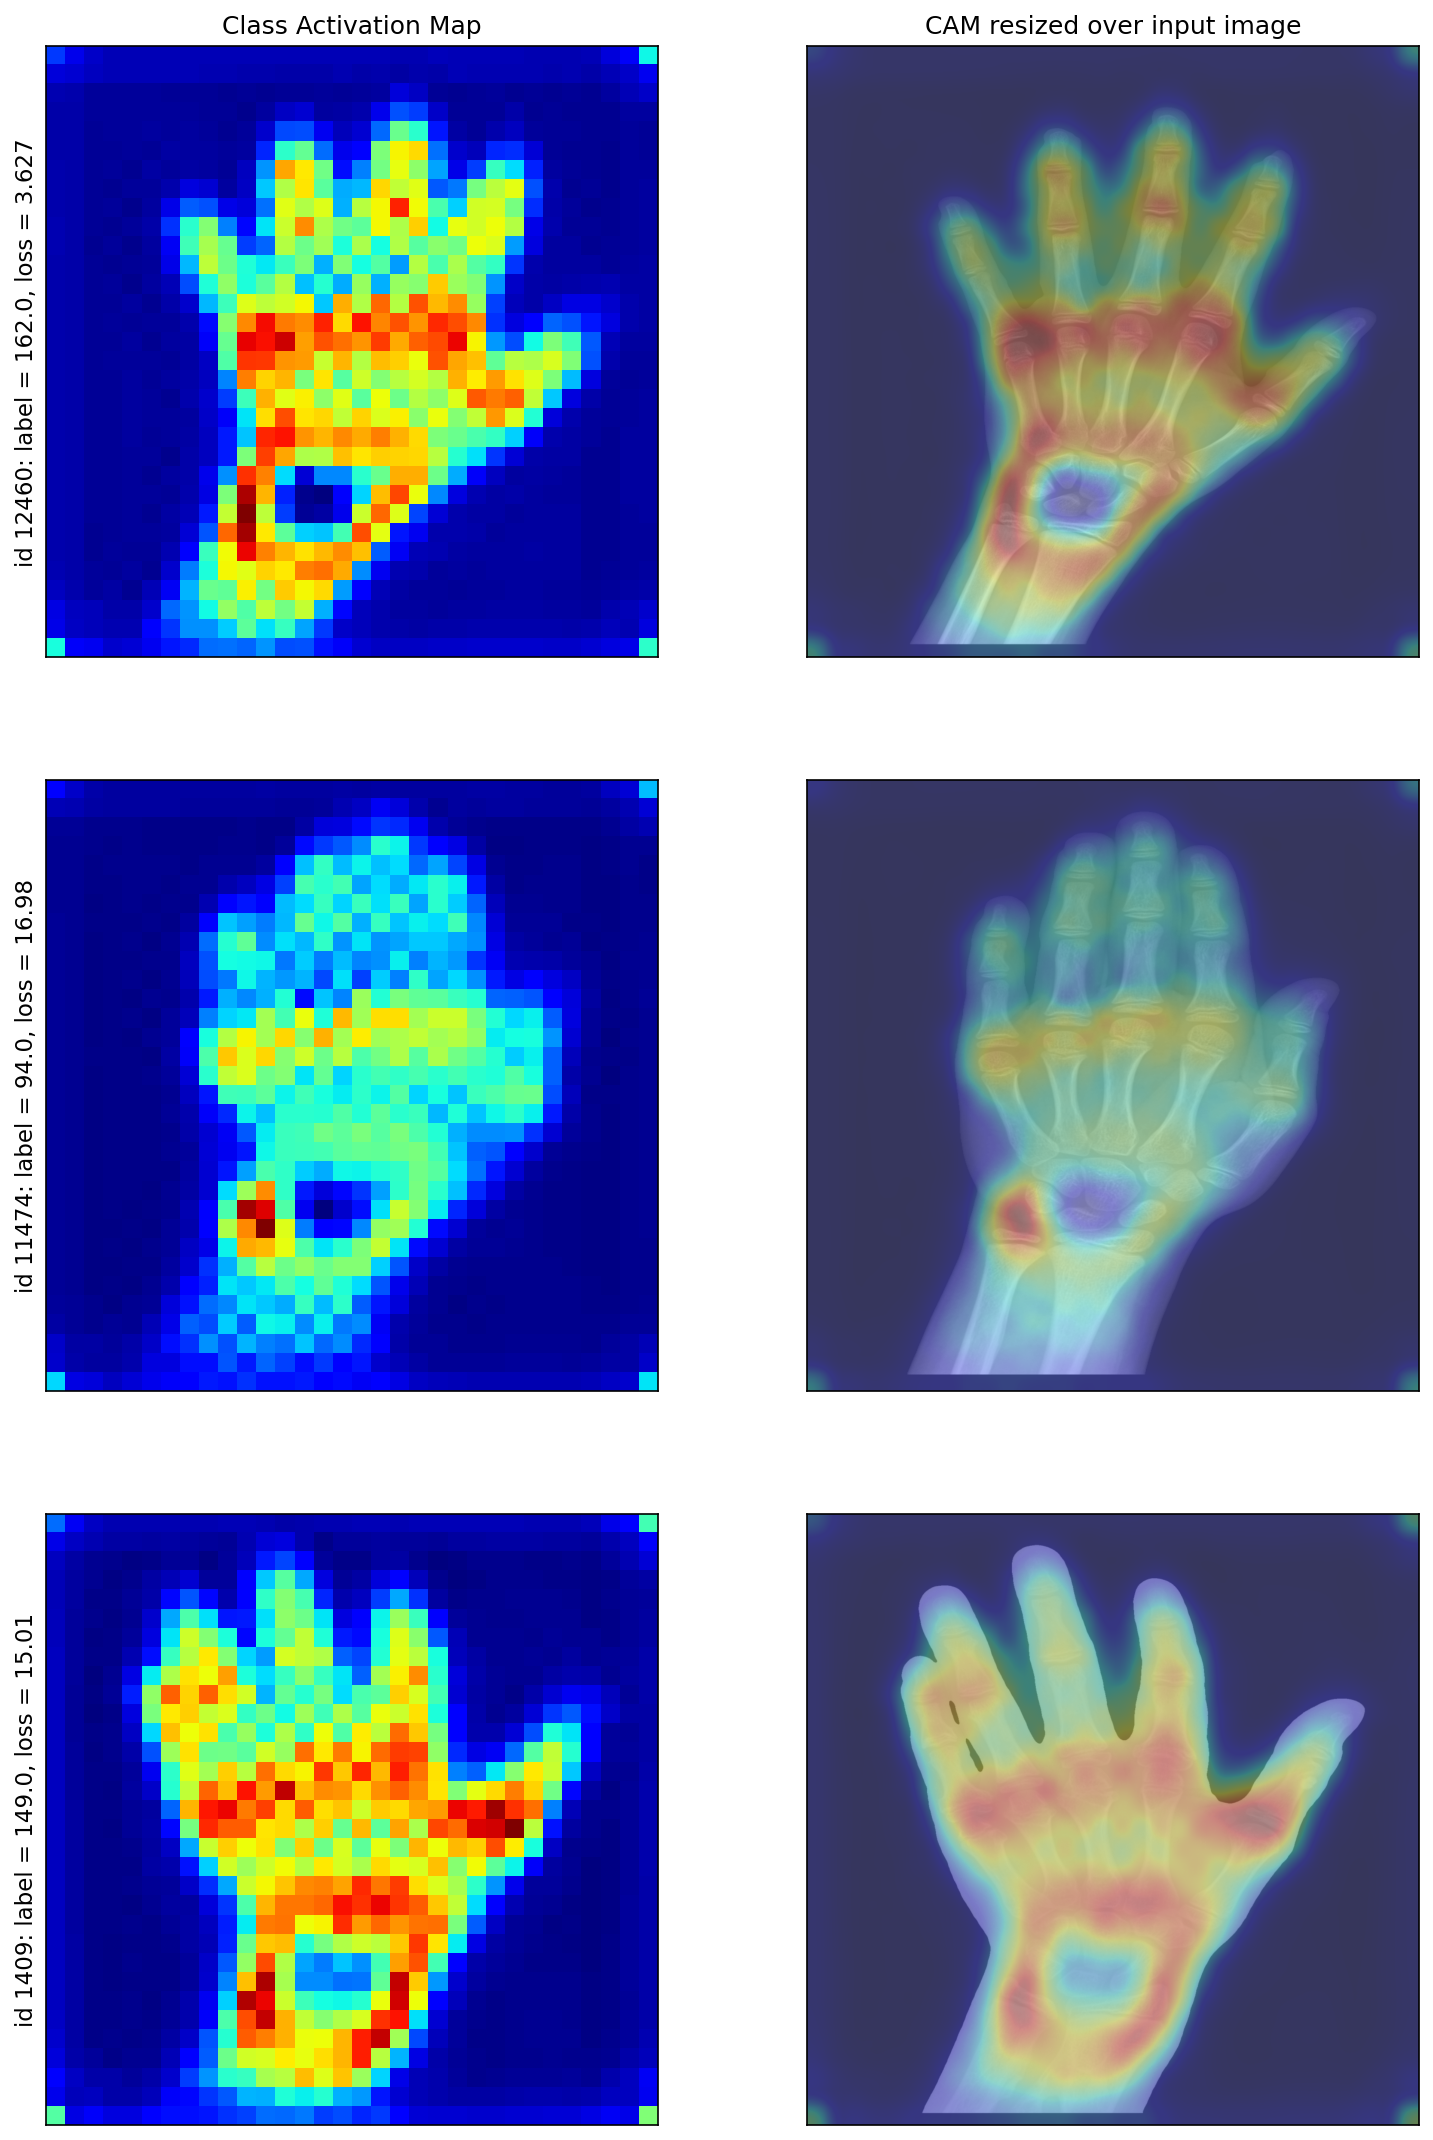

In [213]:
fig, ax = plt.subplots(nrows=nrows, ncols=2, figsize=(6 * 2, 6 * nrows), dpi=150)

for i in range (nrows):

    sub_plot.set_aspect('equal')
    
    img, gender, age, idx = rand_inputs[i]
    u_img = img.unsqueeze(0).to(device)
    u_gender = gender.unsqueeze(0).to(device)

    cam = grad_cam.generate(u_img, u_gender)
    cam = cam.cpu()
    resized_cam = grad_cam.resize_cam(cam, target_image_size)

    pred = model(u_img, u_gender)

    cam = cam.squeeze().detach().numpy()

    ax[i][0].imshow(cam, cmap='jet', alpha=1.0)
    ax[i][0].set_ylabel(f"id {idx}: label = {age:.4}, loss = {criterion(age, pred.squeeze(0)):.4}", fontsize = 11)
    ax[i][0].set_xticks([])
    ax[i][0].set_yticks([])

    img = denormalize(img).squeeze(0).cpu()
    
    # if 3 color channels:
    img = img.permute(1, 2, 0)
    
    ax[i][1].imshow(img, cmap='gray', alpha=0.7)
    ax[i][1].imshow(resized_cam, cmap='jet', alpha=0.3)
    ax[i][1].set_xticks([])
    ax[i][1].set_yticks([])

    if i == 0:
        ax[i][0].set_title("Class Activation Map")
        ax[i][1].set_title("CAM resized over input image")


    print(f"row {i}", end="\r")


p = path.join(output_dir, f"multiple_rand__cam_vs_resized")
makedirs(p, exist_ok=True)

filename = f"{nrows}_rand_samples_cam_vs_resized_{len(listdir(p))}.png"
plt.savefig(path.join(p, filename), dpi=300, bbox_inches='tight')
print(filename)